# PREDICT DIABETES HEALTHCARE
**Author:** ADITYA PRAKASH
**Date:** April 14, 2026


In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns


In [28]:
proj_data = pd.read_csv(r'C:\Users\adity\Downloads\Aditya Prakash - diabetes-data.csv')

In [38]:
proj_data.head() #shows first five rows


,ï»¿Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [36]:
proj_data.info(verbose=True)  #shows the datatype of the values


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ï»¿Pregnancies            768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [40]:
proj_data.describe() #generating descriptive statistics overview for all numberical coloumns in the dataset.

,ï»¿Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [42]:
proj_data.describe().T #tranposed descriptive summary for better readability

,count,mean,std,min,25%,50%,75%,max
ï»¿Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [58]:
proj_data_copy = proj_data.copy(deep=True) #data frame ki copy bana rhi hai

cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
proj_data_copy[cols] = proj_data_copy[cols].replace(0, np.nan)
#replacing 0 value with NAN for data consistency

In [60]:
proj_data_copy.head()

,ï»¿Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [62]:
print(proj_data_copy.isnull().sum())
#counting the number missing values in each column of the data frame.

ï»¿Pregnancies                0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


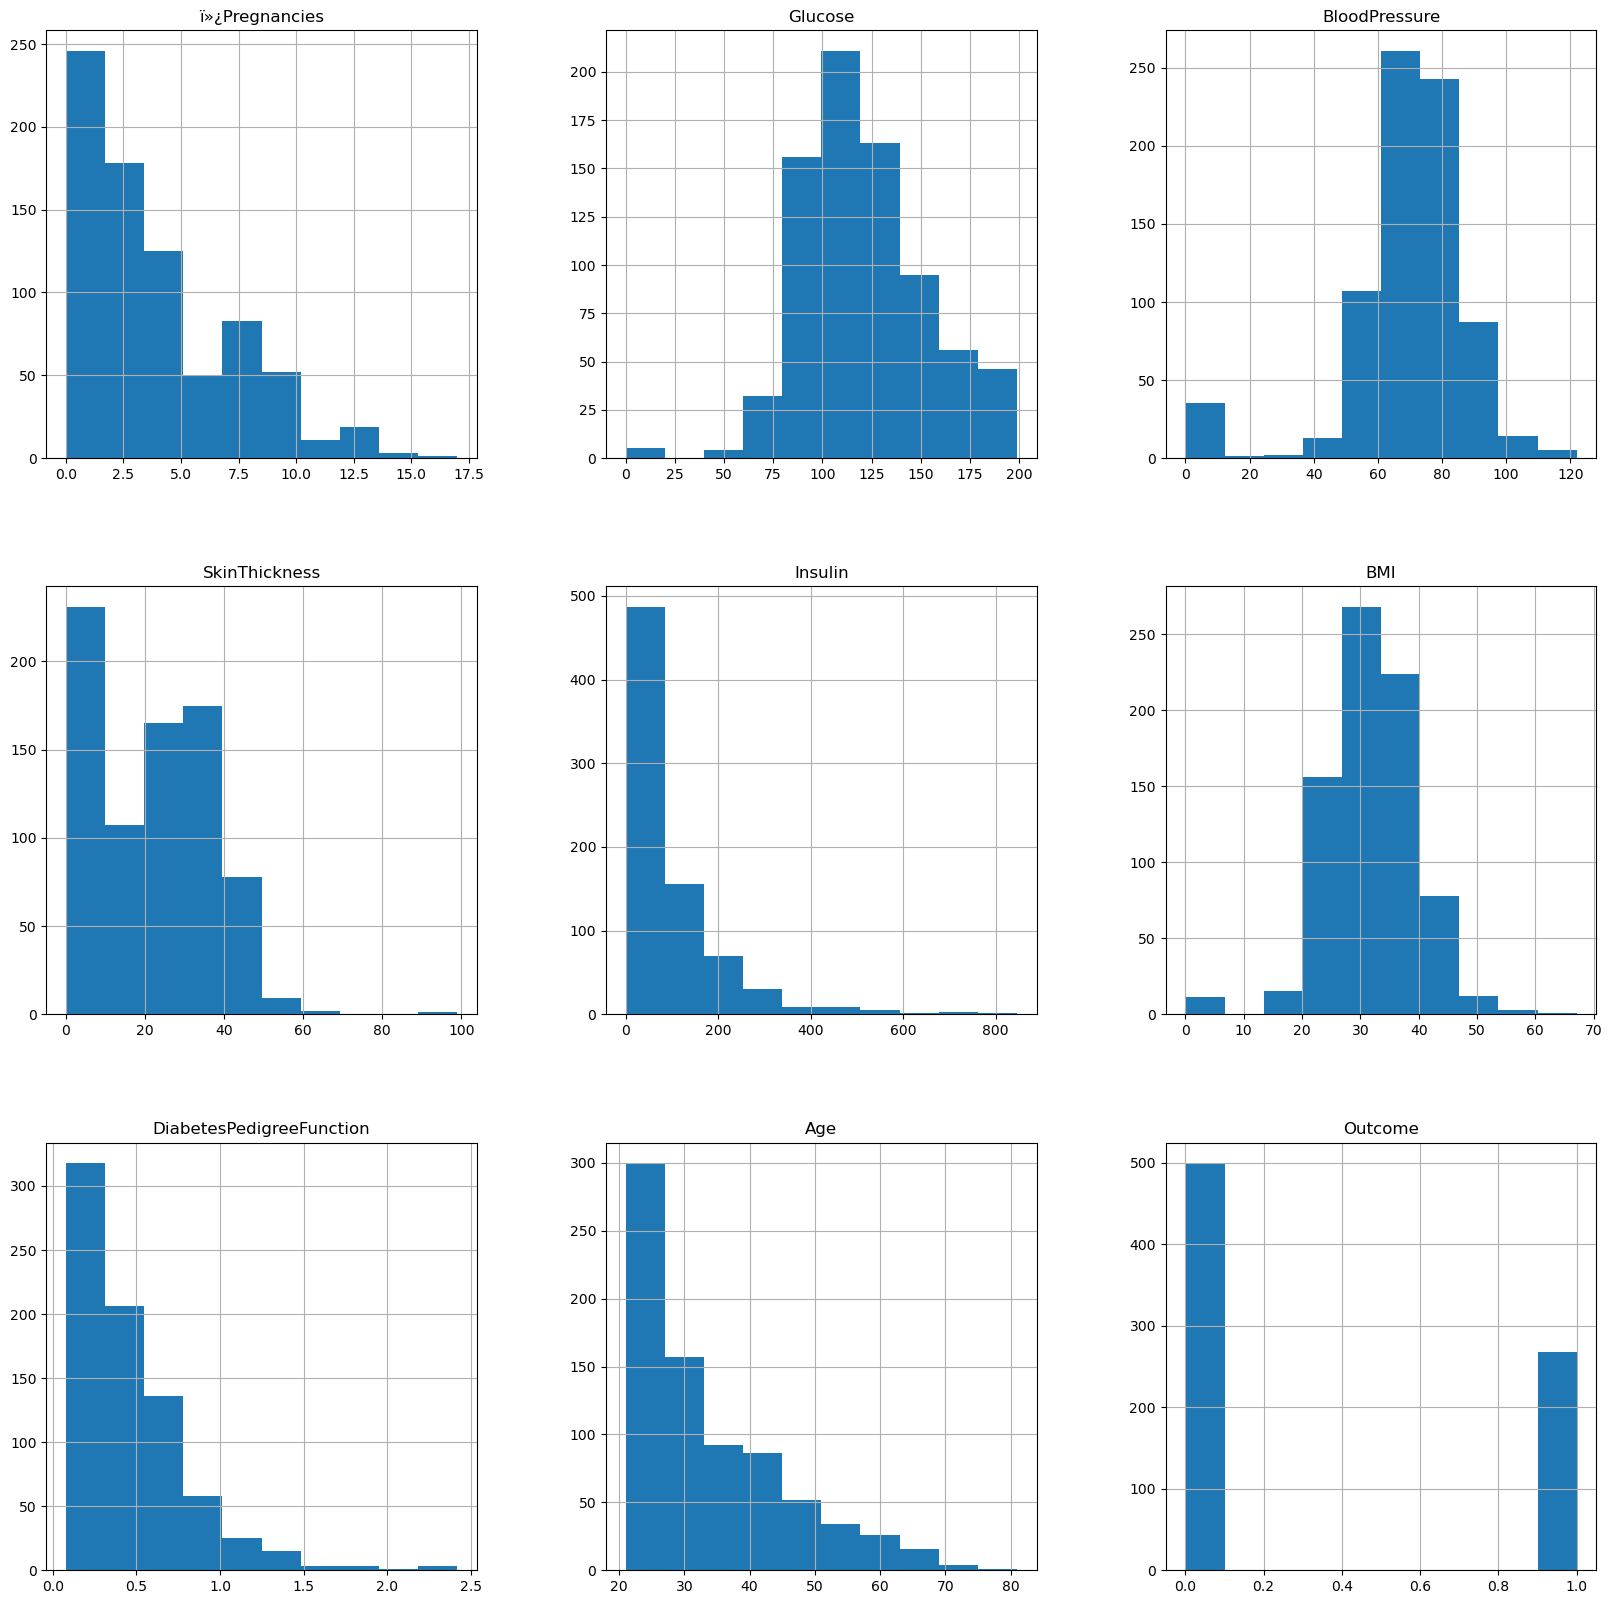

In [64]:
hplot = proj_data.hist(figsize = (20,20))
#ploting histogram to visualize data distrubution for understanding potential baises and spreads

In [70]:
proj_data_copy['Glucose'].fillna(proj_data_copy['Glucose'].mean(), inplace = True)
#imputing missing values for glucose using mean
proj_data_copy['BloodPressure'].fillna(proj_data_copy['BloodPressure'].mean(), inplace = True)
#imputing missing values for blood pressure using mean
proj_data_copy['SkinThickness'].fillna(proj_data_copy['SkinThickness'].median(), inplace = True)
#imputing missing values for skinthickness using median.
proj_data_copy['Insulin'].fillna(proj_data_copy['Insulin'].median(), inplace = True)
#imputing missing values of insulin using median.
proj_data_copy['BMI'].fillna(proj_data_copy['BMI'].median(), inplace = True)
#imputing missing values of BMI using median.


C:\Users\adity\AppData\Local\Temp\ipykernel_38908\2920301795.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  proj_data_copy['Glucose'].fillna(proj_data_copy['Glucose'].mean(), inplace = True)
C:\Users\adity\AppData\Local\Temp\ipykernel_38908\2920301795.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values 

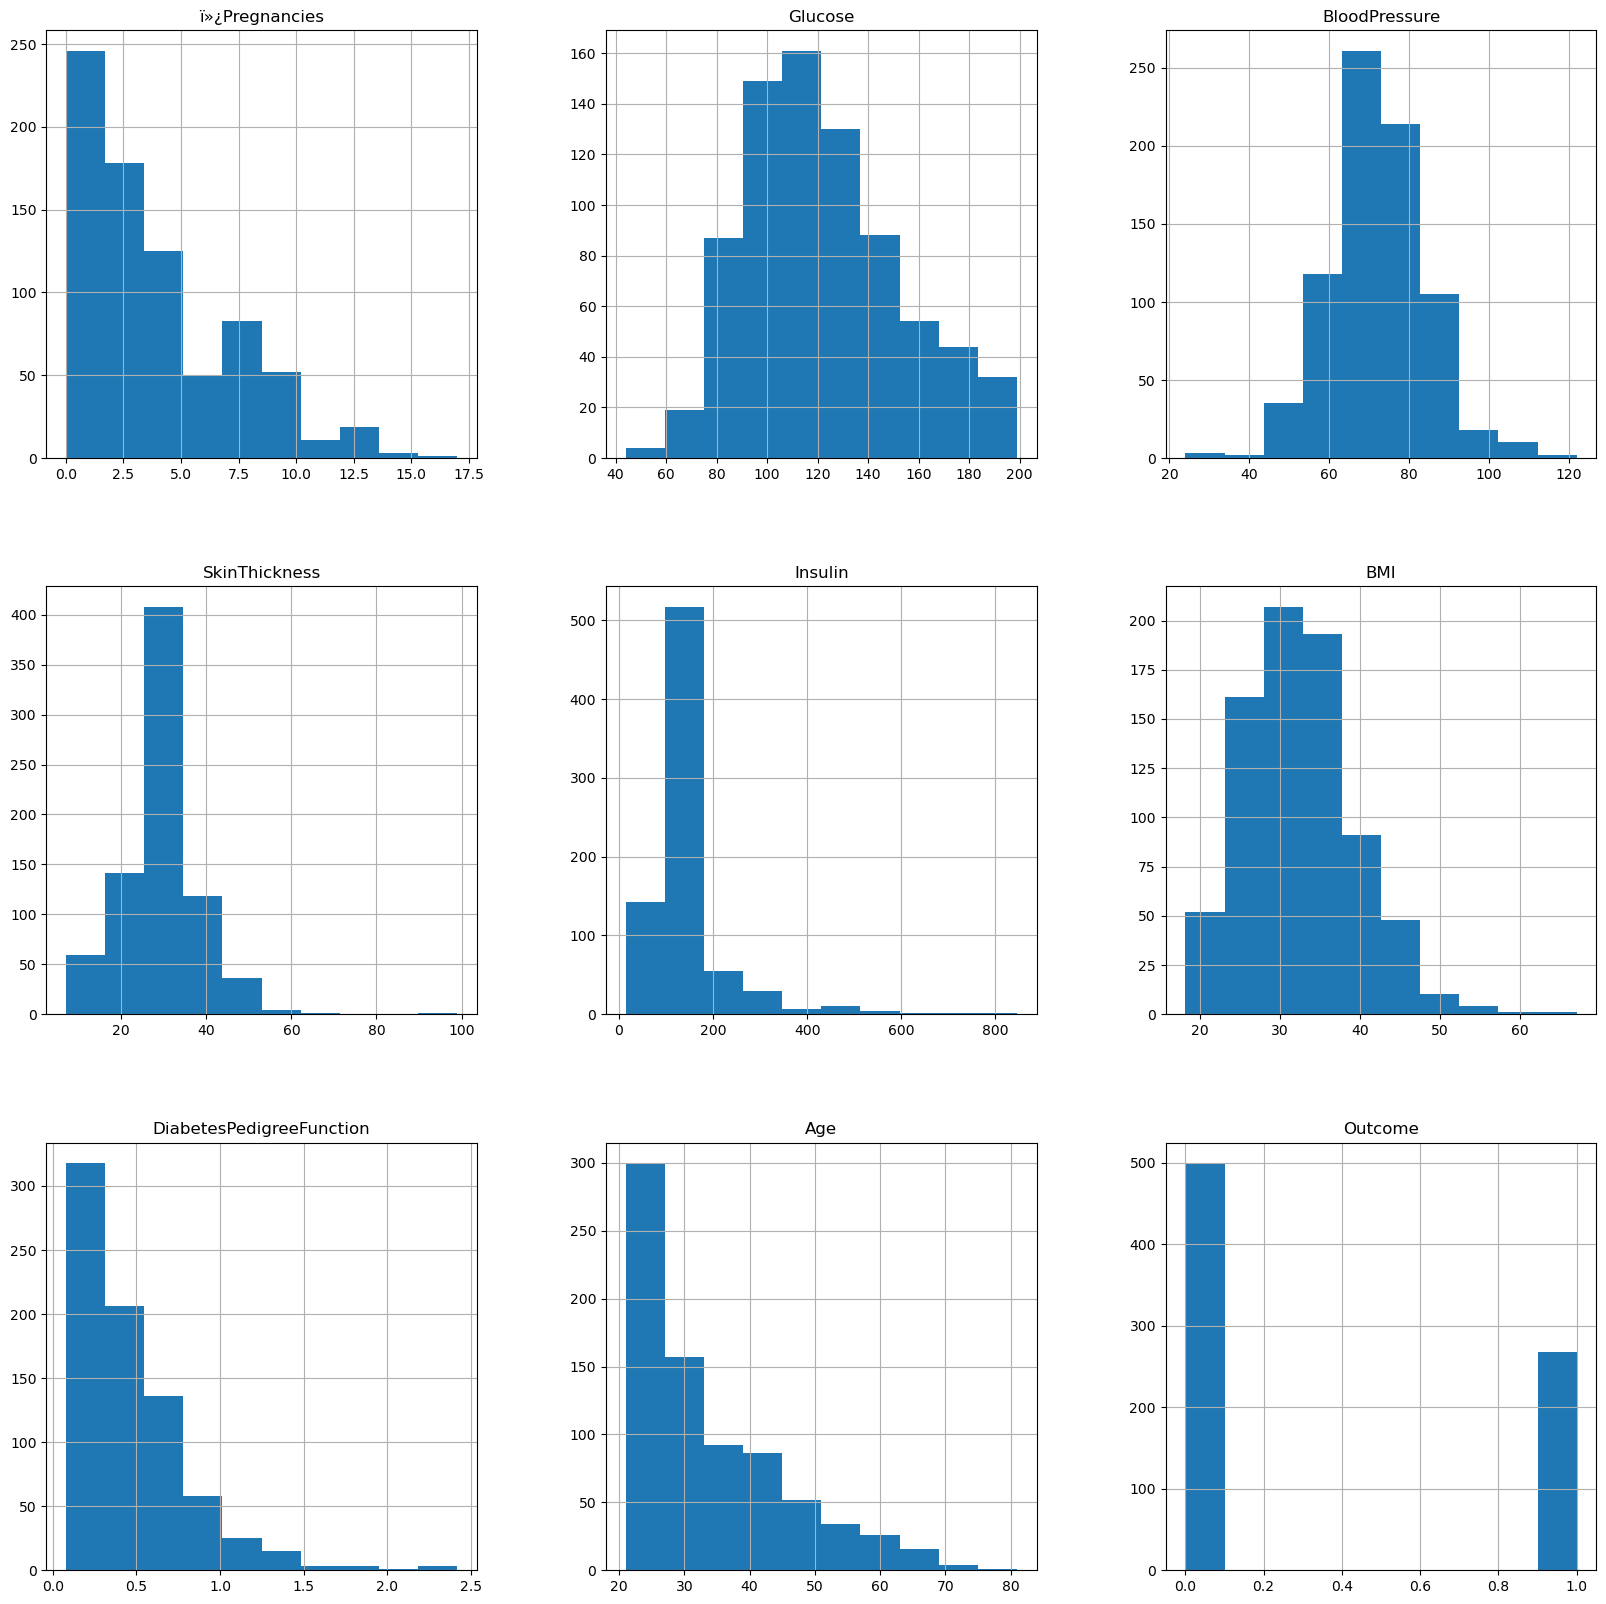

In [72]:
hplot = proj_data_copy.hist(figsize = (20,20))
#plotting histogram of check the data distrubtion after imputing missing values.


In [74]:
proj_data.shape #checking the dimesions of the data frame showing the total no. of records and variables.

(768, 9)

In [76]:
print(proj_data.Outcome.value_counts()) #counting the occurence of each class in the variable.

Outcome
0    500
1    268
Name: count, dtype: int64


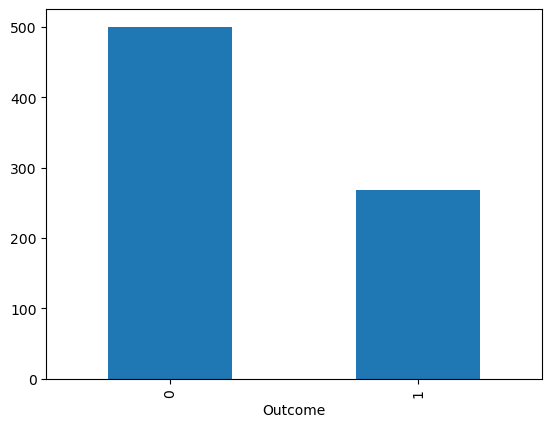

In [78]:
p=proj_data.Outcome.value_counts().plot(kind="bar") #creating a bar chart to visualize the outcome of variable.

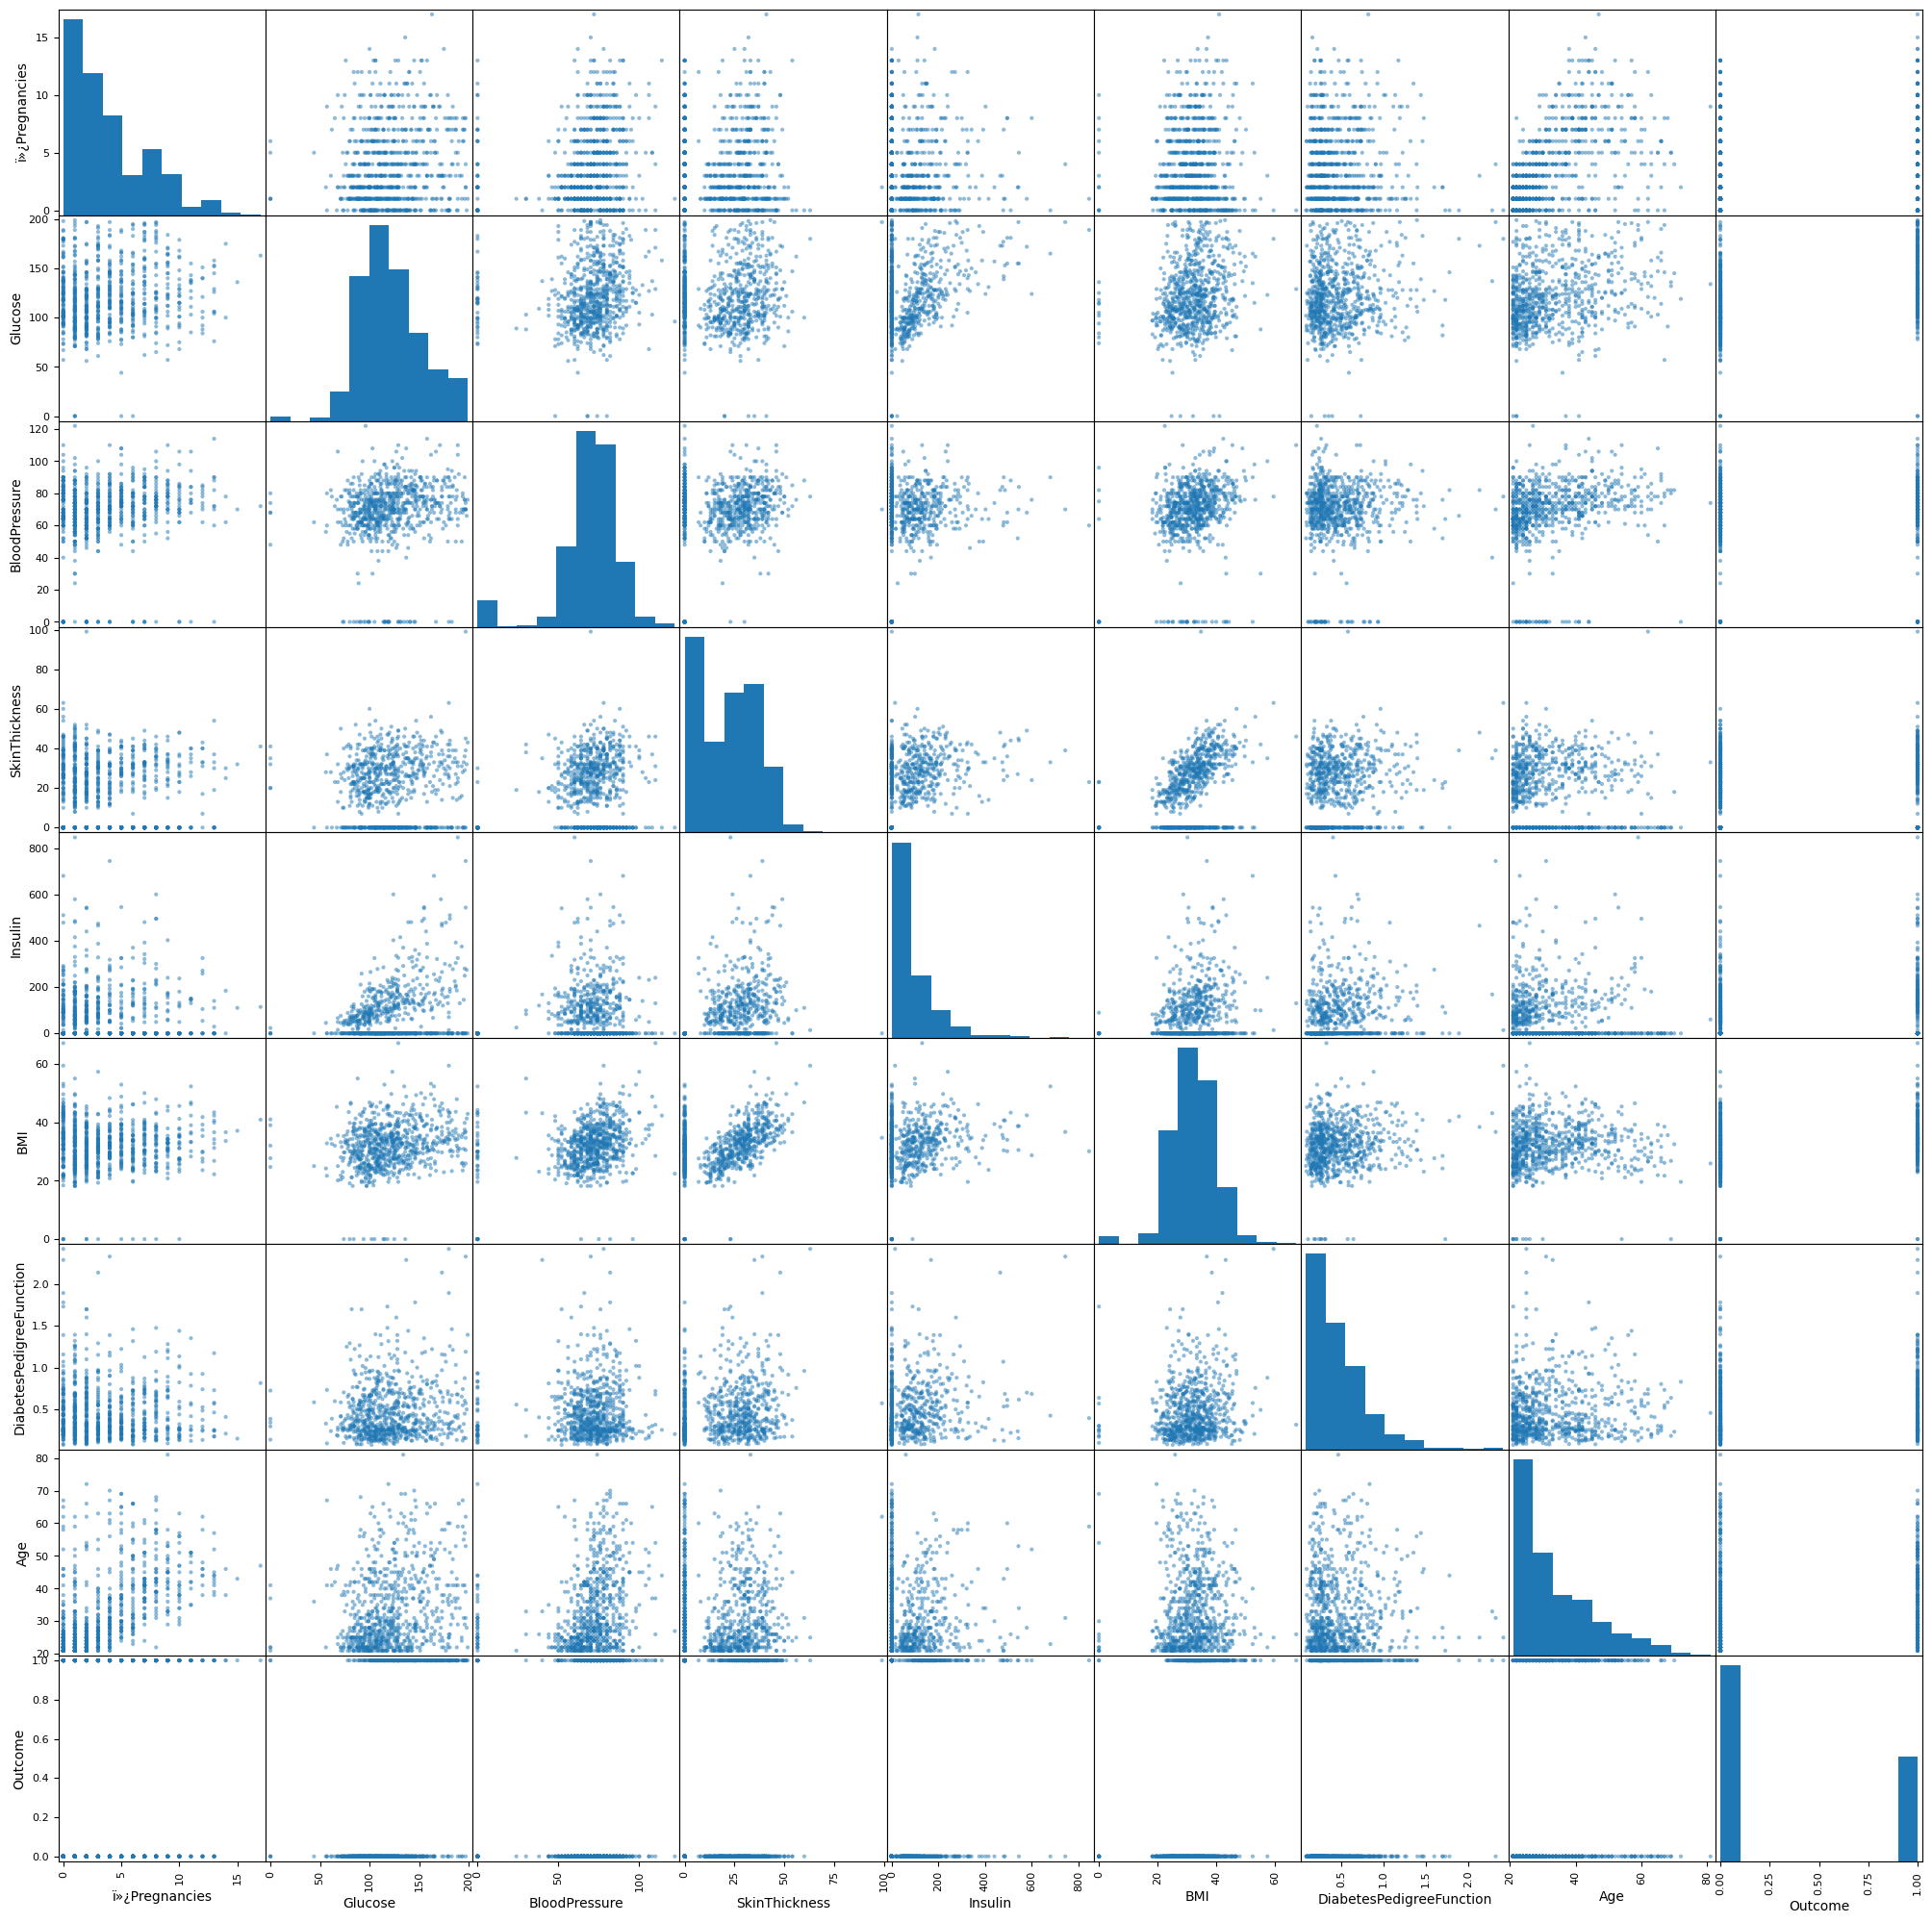

In [82]:
from pandas.plotting import scatter_matrix
p=scatter_matrix(proj_data,figsize=(25,25))

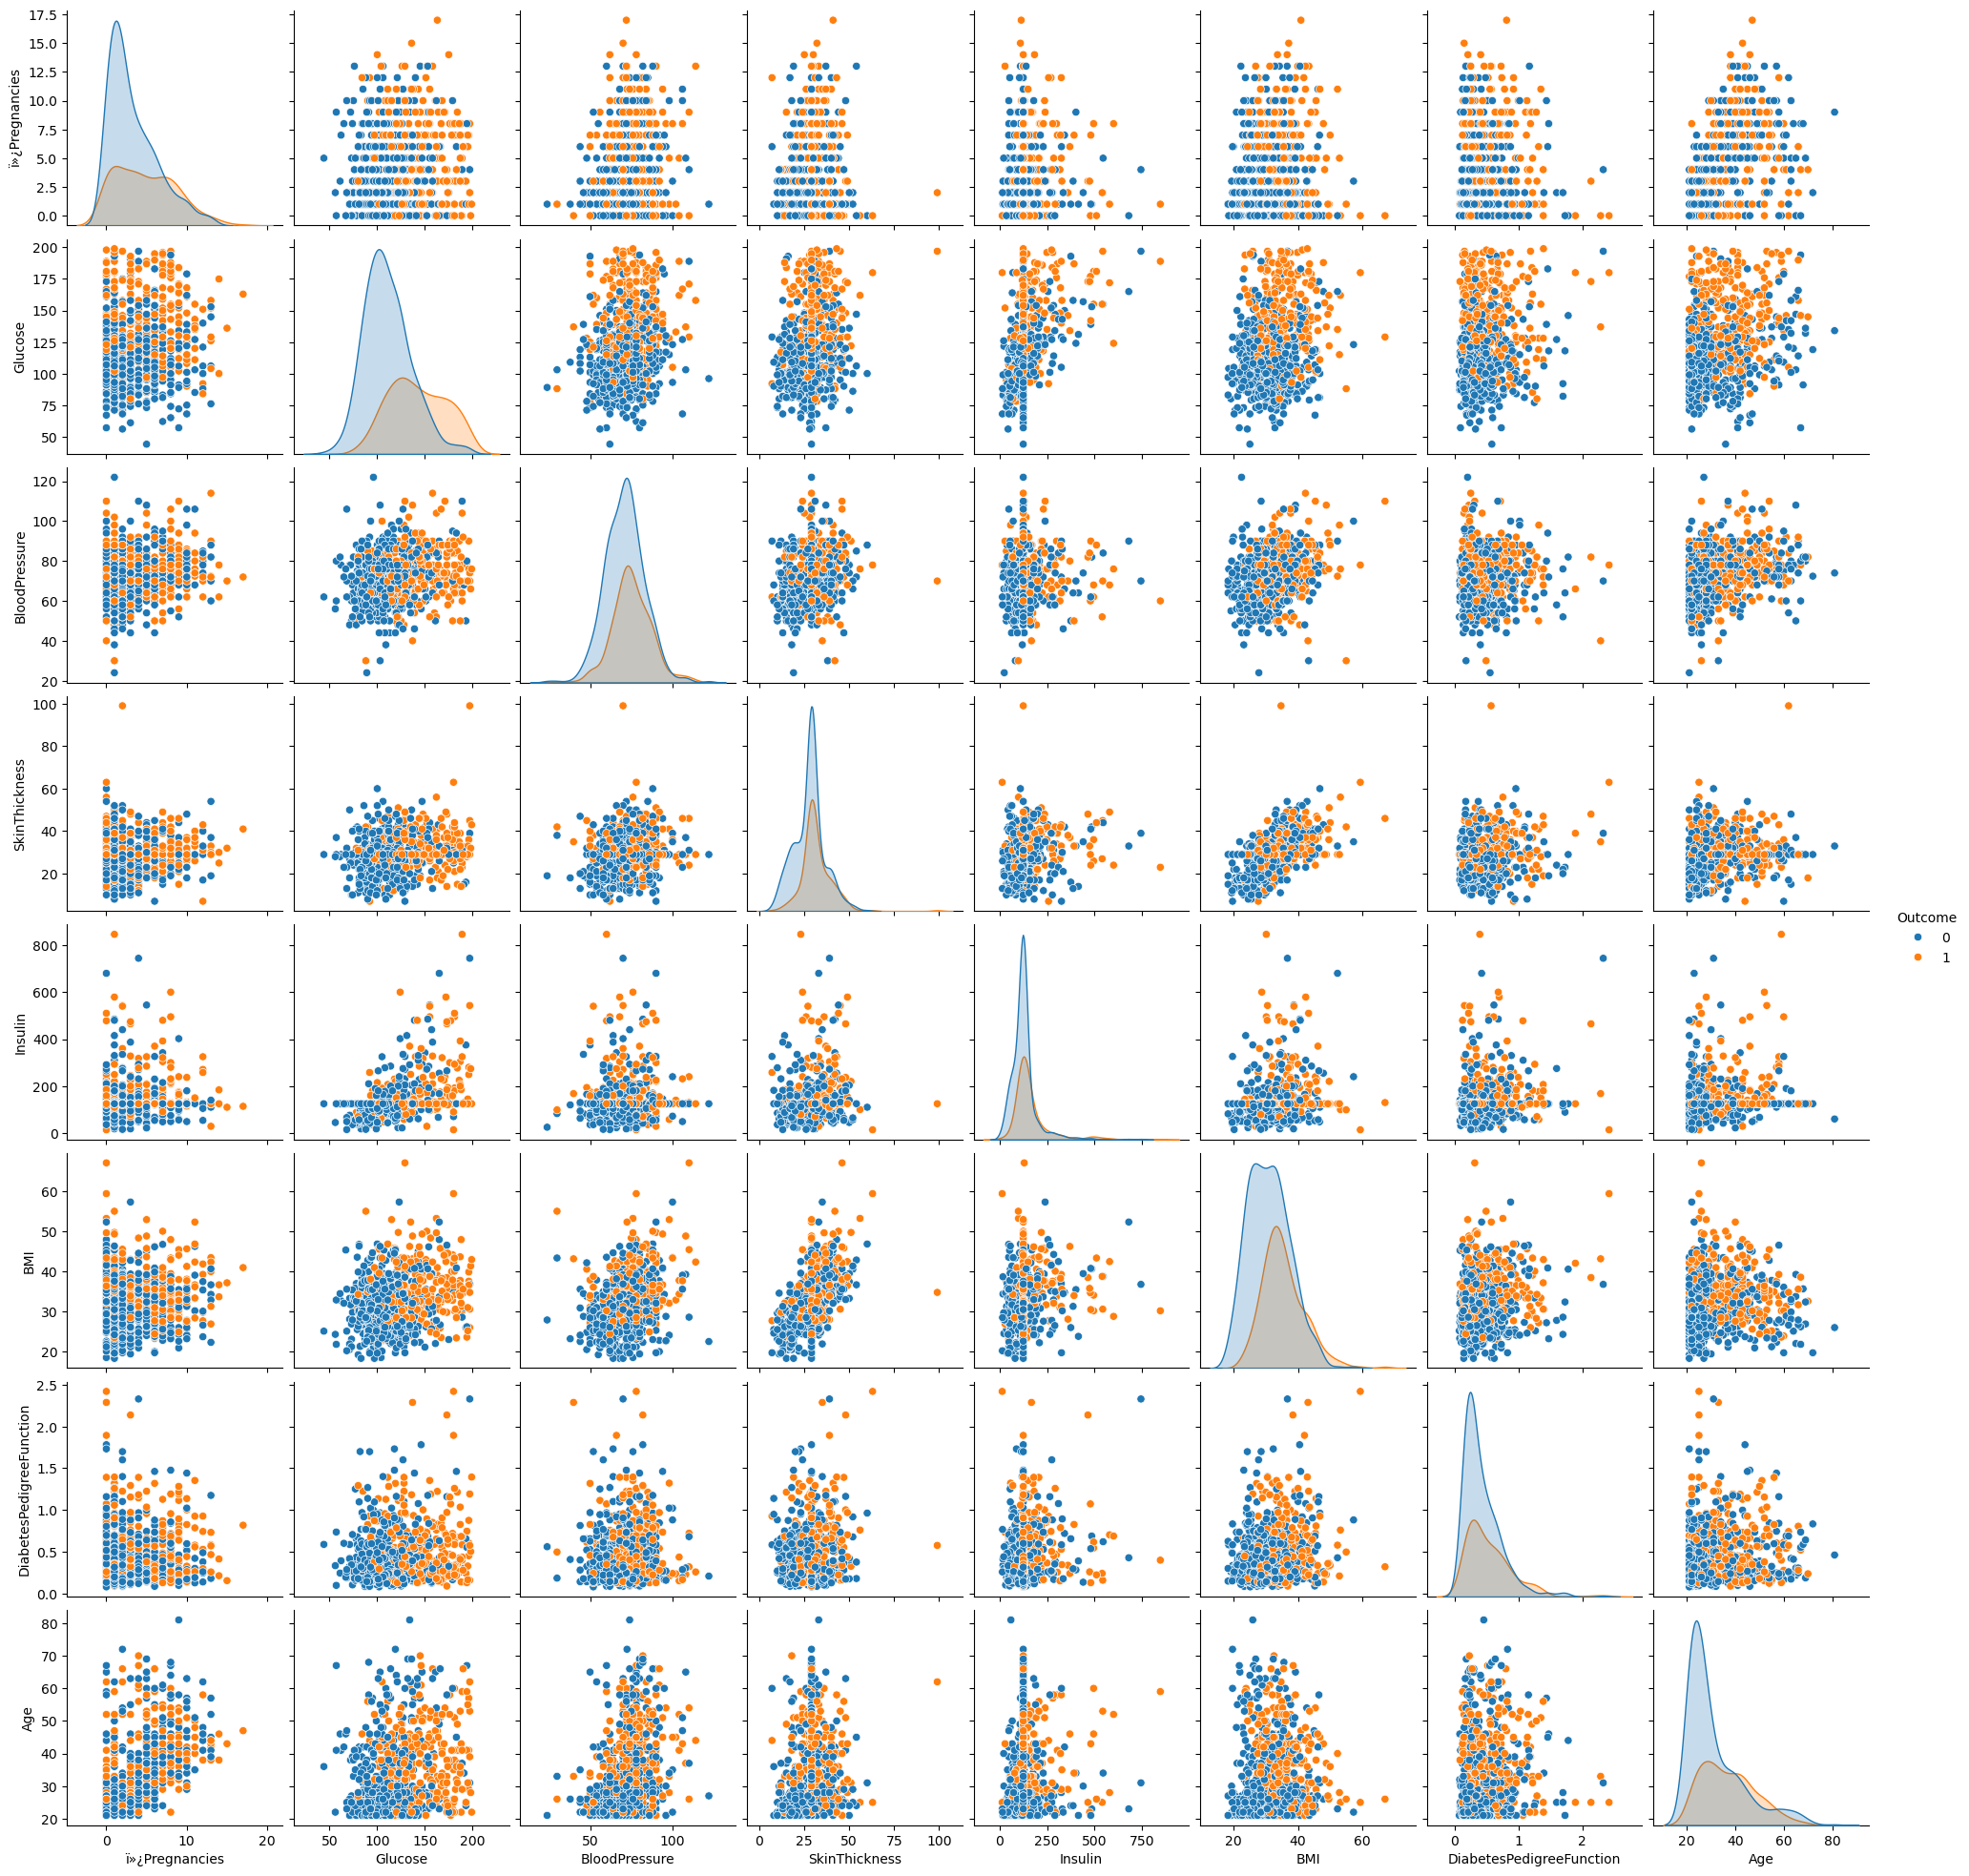

In [85]:
p=sns.pairplot(proj_data_copy, hue='Outcome')
#it creates a grid of plot showing relationship between different variables and points are coloured based on outcome variable.

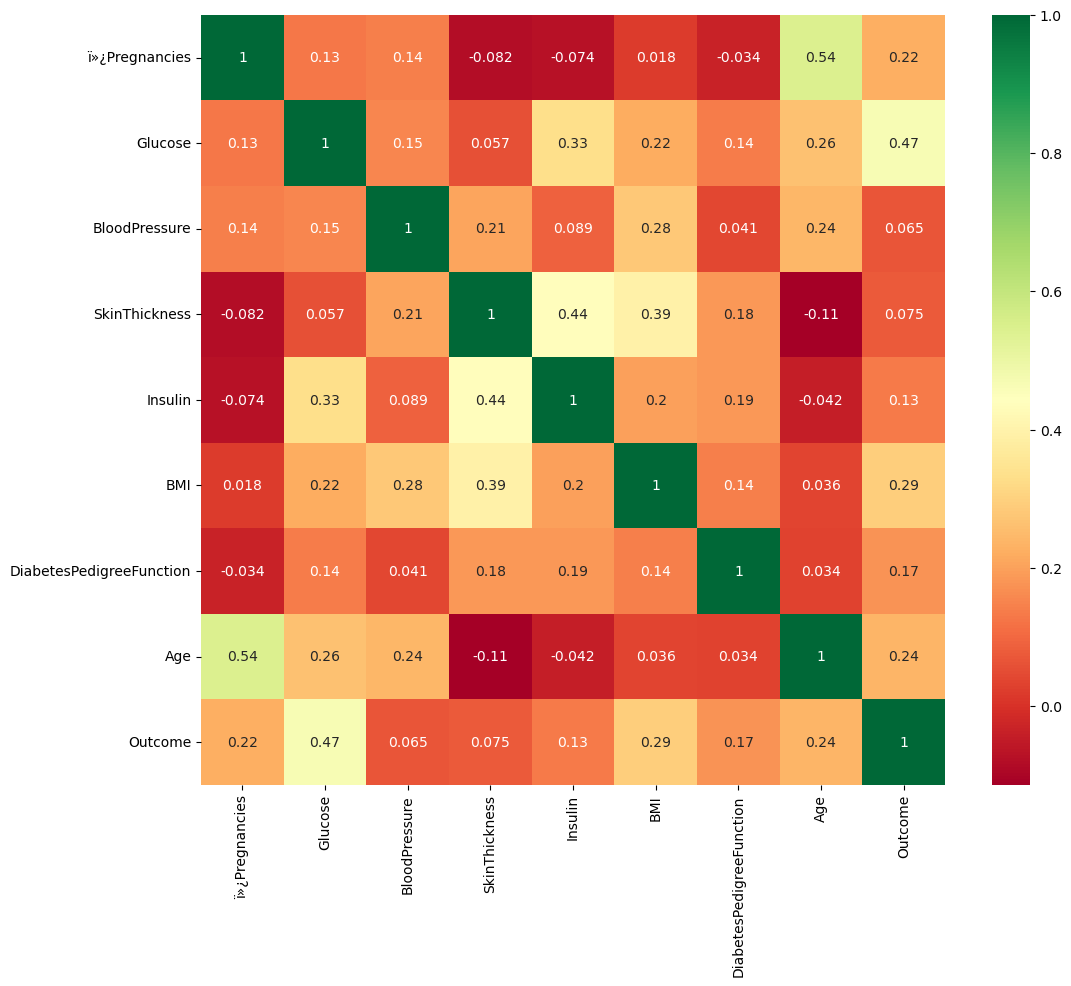

In [87]:
plt.figure(figsize=(12,10)) #increase the size fo figure so we can see the heatmap correctly
p=sns.heatmap(proj_data.corr(), annot=True,cmap ='RdYlGn')
# sets the correlation between variables 

In [89]:
from sklearn.preprocessing import StandardScaler
scale_X = StandardScaler()
X = scale_X.fit_transform(proj_data_copy.drop(["Outcome"],axis = 1),)
X = pd.DataFrame(X,columns=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'])
#the code rescale variables values to a common scale so tha t all variable can contribute to the model analysis.

In [93]:
X.head() #SHOWS FIRST 5 ROWS 

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.865108,-0.033518,0.670643,-0.181541,0.166619,0.468492,1.425995
1,-0.844885,-1.206162,-0.529859,-0.012301,-0.181541,-0.852200,-0.365061,-0.190672
2,1.233880,2.015813,-0.695306,-0.012301,-0.181541,-1.332500,0.604397,-0.105584
3,-0.844885,-1.074652,-0.529859,-0.695245,-0.540642,-0.633881,-0.920763,-1.041549
4,-1.141852,0.503458,-2.680669,0.670643,0.316566,1.549303,5.484909,-0.020496


In [95]:
y = proj_data_copy.Outcome
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=1/3,random_state=42, 
stratify=y)
## Split the dataset into training and testing sets, ensuring the 'Outcome' distribution is maintained


In [103]:
from sklearn.neighbors import KNeighborsClassifier
testing_score = []
training_score = []
for i in range(1,15):
    knn = KNeighborsClassifier(i)
    knn.fit(X_train,y_train)
    training_score.append(knn.score(X_train,y_train))
    testing_score.append(knn.score(X_test,y_test))
    #intilizae and train a k nearest classifier by iterating through diffrnet values of K to find the optimal solution.


In [101]:
max_training_score = max(training_score)
train_scores_ind = [i for i, v in enumerate(training_score) if v == max_training_score]
print('Max training score {} % and k = {}'.format(max_training_score*100,list(map(lambda x: 
x+1, train_scores_ind)))) 
#calculating the accuracy score for b0th training testing data at reach itertaion of k vales.

Max training score 100.0 % and k = [1]


In [107]:
max_testing_score = max(testing_score)

test_scores_ind = [i for i, v in enumerate(testing_score) if v == max_testing_score]

k_values = [i + 1 for i in test_scores_ind]

print("Max testing score {:.4f} % and k = {}".format(max_testing_score * 100, k_values))
#finding the optimal result by determining the k vales that maximizing the testing accuracy for th model.

Max testing score 76.5625 % and k = [11]


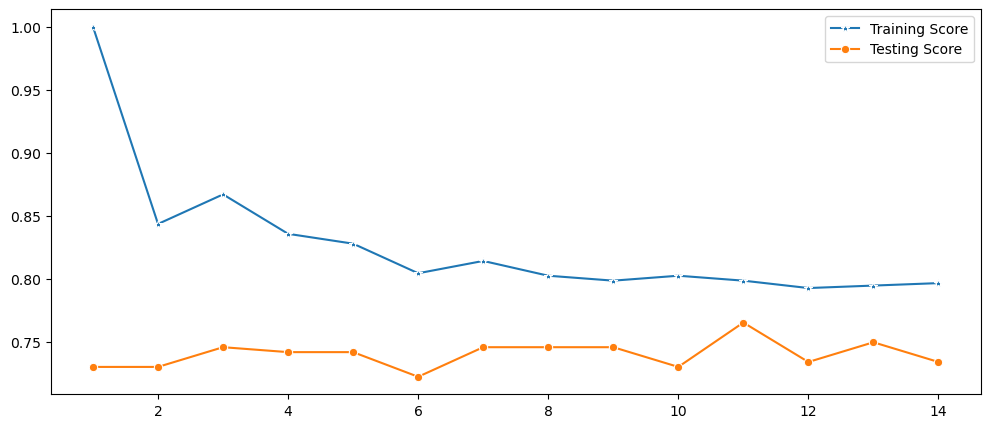

In [120]:
plt.figure(figsize=(12,5))
pplot = sns.lineplot(x=range(1, 15), y=training_score, marker='*', label='Training Score')
pplot = sns.lineplot(x=range(1, 15), y=testing_score, marker='o', label='Testing Score')
## Plot training and testing scores to compare model performance
## Plot training and testing scores to compare model performance

In [124]:
# Initialize KNN classifier with 11 neighbors
knn = KNeighborsClassifier(11)

# Train the model using training data
knn.fit(X_train, y_train)

# Evaluate and return accuracy score on test data
knn.score(X_test, y_test)

0.765625